Calculate the game value of a given game

In [1]:
import functools

In [2]:
def mex(s):  # Min excludant (minimum number not in the list), helper function
    i = 0
    while i in s:
        i += 1
    return i

@functools.lru_cache(maxsize=None)
def sg_value(piles):
    piles = tuple(sorted(piles)) # Reduce cases: e.g. (2,5) and (5,2) are the same

    if all(p == 0 for p in piles): # if every pile has no stone, game value is 0
        return 0

    moves = set() # Create a set object
    for i in range(len(piles)): # Choose a pile to remove stones from
        for k in range(1, piles[i] + 1): # Choose how many stones to remove
            # Create a new state (where k stones are removed from pile i)
            new_piles = list(piles)
            new_piles[i] -= k

            # Recursive step + store calculated game values
            moves.add(sg_value(tuple(new_piles)))
    result = mex(moves)
    return result

In [3]:
print('SG (3,3):', sg_value((3,3)))     # 0 → 2nd wins (mirror)[file:1]
print('SG (5,3):', sg_value((5,3)))     # 6 ≠0 → 1st wins (to (3,3))
print('SG (5,7,9):', sg_value((5,7,9))) # 11 ≠0 → reduce 9 to 2
print('XOR check:', 5 ^ 7 ^ 9)          # 11 (matches SG for Nim!)

SG (3,3): 0
SG (5,3): 6
SG (5,7,9): 11
XOR check: 11


Add a game simulator for optimal games

In [4]:
import random

In [5]:
def play_optimal_game(start_piles, max_moves = 10000):
  piles = list(start_piles)
  moves = 0
  while moves < max_moves and any(p>0 for p in piles):
    sg = sg_value(tuple(piles)) # Calculate the sg value of pile
    if (sg == 0): # Losing position for the current player
      i = random.choice([idx for idx, p in enumerate(piles) if p>0]) # Choose a random pile to remove stones from
      k = random.randint(1,piles[i]) # Choose a random number of stones to remove from pile i
      piles[i] -= k # Update pile
    else:
      found_move = False
      for i in range(len(piles)):
        for k in range(1,piles[i]+1):
          new_piles = list(piles)
          new_piles[i] -= k
          if sg_value(tuple(new_piles)) == 0: # Choose the position such that sg = 0
            piles = new_piles
            found_move = True
            break
        if found_move: break

    moves += 1
  winner = 1 if (moves % 2 != 0) else 2
  return winner, moves

In [6]:
print(play_optimal_game((3,3)))   # (2, 6) → 2nd wins in 6 moves
print(play_optimal_game((5,3)))   # (1, ~4)

(2, 4)
(1, 5)


Verify using 1000 random cases

In [7]:
import numpy as np

def verify_nim_experiment(n_games=10000, max_piles=5, max_size=20):
    print(f"Running {n_games} simulations...")

    correct_predictions = 0
    sg_zero_wins_for_p2 = 0    # How many times P2 won when starting SG was 0
    sg_nonzero_wins_for_p1 = 0 # How many times P1 won when starting SG was NON-zero

    avg_game_lengths = []

    for i in range(n_games):
        # 1. Generate Random Game
        num_piles = np.random.randint(1, max_piles + 1)
        piles = tuple(np.random.randint(1, max_size + 1, num_piles))

        # 2. Predict Winner using SG
        start_sg = sg_value(piles)
        predicted_winner = 2 if start_sg == 0 else 1

        # 3. Simulate Game (Optimal Play)
        actual_winner, moves = play_optimal_game(piles)
        avg_game_lengths.append(moves)

        # 4. Check Prediction
        if actual_winner == predicted_winner:
            correct_predictions += 1

        # 5. Track Statistics
        if start_sg == 0 and actual_winner == 2:
            sg_zero_wins_for_p2 += 1
        elif start_sg != 0 and actual_winner == 1:
            sg_nonzero_wins_for_p1 += 1

        # Optional: Print progress every 1000 games
        if (i+1) % 2000 == 0:
            print(f"  Simulated {i+1} games...")

    # Results
    accuracy = (correct_predictions / n_games) * 100
    avg_len = np.mean(avg_game_lengths)

    print("\n=== Experiment 1 Results ===")
    print(f"Total Games: {n_games}")
    print(f"SG Prediction Accuracy: {accuracy:.2f}%")
    print(f"Average Game Length: {avg_len:.2f} moves")
    print(f"Breakdown:")
    print(f"  SG=0 games (Predicted P2): P2 won {sg_zero_wins_for_p2} times")
    print(f"  SG!=0 games (Predicted P1): P1 won {sg_nonzero_wins_for_p1} times")

    return accuracy, avg_len

# Run it!
verify_nim_experiment()

Running 10000 simulations...
  Simulated 2000 games...
  Simulated 4000 games...
  Simulated 6000 games...
  Simulated 8000 games...
  Simulated 10000 games...

=== Experiment 1 Results ===
Total Games: 10000
SG Prediction Accuracy: 100.00%
Average Game Length: 8.24 moves
Breakdown:
  SG=0 games (Predicted P2): P2 won 297 times
  SG!=0 games (Predicted P1): P1 won 9703 times


(100.0, np.float64(8.2375))

## Train a simple Neural Network to learn how to play Nim

1. Create our training data

In [11]:
import numpy as np

def generate_nim_data(num_samples=10000, max_piles=5, max_size=15):
    inputs = []
    targets = [] # Which pile index (0-4) is best?

    print(f"Generating {num_samples} training examples...")

    for _ in range(num_samples):
        # Create random game state
        num_piles = np.random.randint(1, max_piles + 1)
        piles = list(np.random.randint(1, max_size + 1, num_piles))

        # Pad with zeros to fixed size (e.g., always 5 inputs)
        padded_piles = piles + [0] * (max_piles - len(piles))

        # Find Optimal Move
        sg = sg_value(tuple(piles))

        if sg == 0:
            # Losing position - No good move exist. Skip or label randomly?
            # Let's skip losing positions for training optimal policy!
            continue

        # Find winning move index
        best_pile_idx = -1
        for i in range(len(piles)):
            for k in range(1, piles[i] + 1):
                new_piles = list(piles)
                new_piles[i] -= k
                if sg_value(tuple(new_piles)) == 0:
                    best_pile_idx = i
                    break
            if best_pile_idx != -1: break

        inputs.append(padded_piles)
        targets.append(best_pile_idx)

    return np.array(inputs), np.array(targets)

# Generate Data
X_train, y_train = generate_nim_data(num_samples=10000)
X_test, y_test = generate_nim_data(num_samples=2000)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")


Generating 10000 training examples...
Generating 2000 training examples...
Training Data Shape: (9490, 5)
Testing Data Shape: (1908, 5)


In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Create a Neural Network
# Hidden Layers: (64 neurons, 32 neurons) -> Simple brain
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)

# Train!
print("Training Neural Network...")
model.fit(X_train, y_train)

# Evaluate!
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nNeural Network Accuracy: {accuracy * 100:.2f}%")
print("Baseline (Random Guessing): ~20% (1 in 5 piles)")


Training Neural Network...

Neural Network Accuracy: 88.78%
Baseline (Random Guessing): ~20% (1 in 5 piles)


In [16]:
# Add more neurons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Create a Neural Network
# Hidden Layers: (64 neurons, 32 neurons) -> Simple brain
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)

# Train!
print("Training Neural Network...")
model.fit(X_train, y_train)

# Evaluate!
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nNeural Network Accuracy: {accuracy * 100:.2f}%")
print("Baseline (Random Guessing): ~20% (1 in 5 piles)")

Training Neural Network...

Neural Network Accuracy: 88.78%
Baseline (Random Guessing): ~20% (1 in 5 piles)


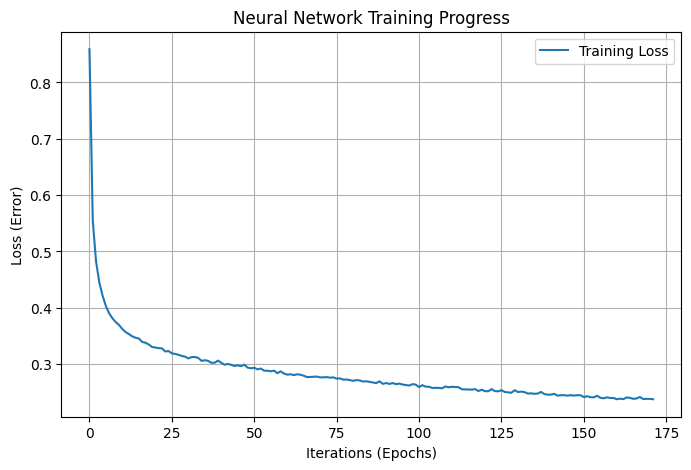

In [17]:
import matplotlib.pyplot as plt

# Plot Training Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, label='Training Loss')
plt.title('Neural Network Training Progress')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True)
plt.show()

## Ordinal Divergence Experiment

Running FAST Ordinal Nim Experiment...
  N=100: Length 203
  N=500: Length 1003
  N=1000: Length 2003
  N=5000: Length 10003
  N=10000: Length 20003
  N=50000: Length 100003


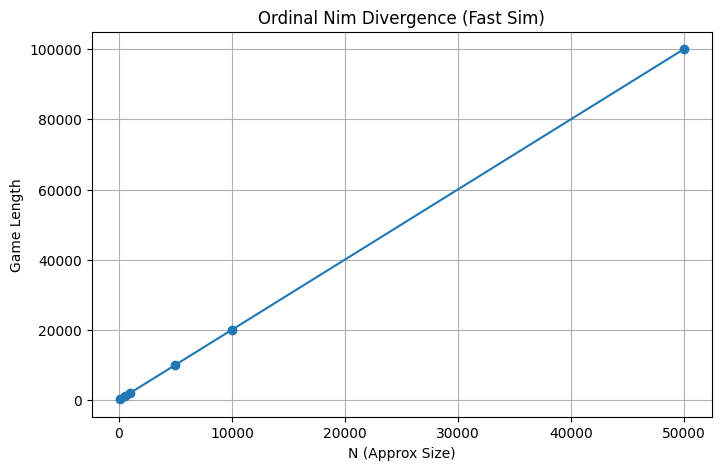

In [21]:
def nim_sum(piles):
    result = 0
    for p in piles:
        result ^= p
    return result

# Modified Play Optimal Game (Uses FAST XOR)
def play_fast_ordinal_game(start_piles):
    piles = list(start_piles)
    moves = 0

    while any(p > 0 for p in piles):
        current_xor = nim_sum(piles)

        if current_xor == 0:
            # Random Move (Losing Position)
            valid = [i for i, p in enumerate(piles) if p > 0]
            i = valid[0] # Just pick first valid pile
            k = 1       # Remove 1 stone
            piles[i] -= k
        else:
            # Winning Move (Use XOR logic)
            found = False
            for i in range(len(piles)):
                target = piles[i] ^ current_xor
                if target < piles[i]:
                    piles[i] = target
                    found = True
                    break
            if not found: break # Should never happen

        moves += 1

    return moves

# Now Run Experiment with FAST version
def simulate_ordinal_nim_fast(N_values=[100, 500, 1000, 5000, 10000, 50000]):
    print("Running FAST Ordinal Nim Experiment...")
    lengths = []

    for N in N_values:
        piles = (3*N + 2, N + 1)
        moves = play_fast_ordinal_game(piles)
        lengths.append(moves)
        print(f"  N={N}: Length {moves}")

    return N_values, lengths

# Run & Plot!
import matplotlib.pyplot as plt
N_vals, lens = simulate_ordinal_nim_fast()

plt.figure(figsize=(8, 5))
plt.plot(N_vals, lens, 'o-')
plt.title("Ordinal Nim Divergence (Fast Sim)")
plt.xlabel("N (Approx Size)")
plt.ylabel("Game Length")
plt.grid(True)
plt.show()
